In [ ]:
!pip install requests pandas matplotlib scikit-learn

1. ADIM: VERİLER DÜNYA BANKASI'NDAN ÇEKİLİYOR...

Kullanılan veri (1995-2024, toplam 30 yıl):
    Year  Issizlik_Orani  Buyume_Orani  Enflasyon
0   1995           7.644      7.878267  89.113317
1   1996           6.629      7.379664  80.412151
2   1997           6.841      7.577664  85.669362
3   1998           6.888      2.404150  84.641343
4   1999           7.687     -3.263168  64.867488
5   2000           6.495      6.933240  54.915371
6   2001           8.381     -5.750007  54.400189
7   2002          10.358      6.447722  44.964121
8   2003          10.542      5.763206  21.602438
9   2004          10.838      9.795936   8.598262
10  2005          10.636      8.992305   8.179160
11  2006          10.227      6.947988   9.597242
12  2007          10.285      5.043508   8.756181
13  2008          10.965      0.815025  10.444128
14  2009          14.026     -4.823154   6.250977
15  2010          11.879      8.427104   8.566444
16  2011           9.789     11.200111   6.471880
17  20

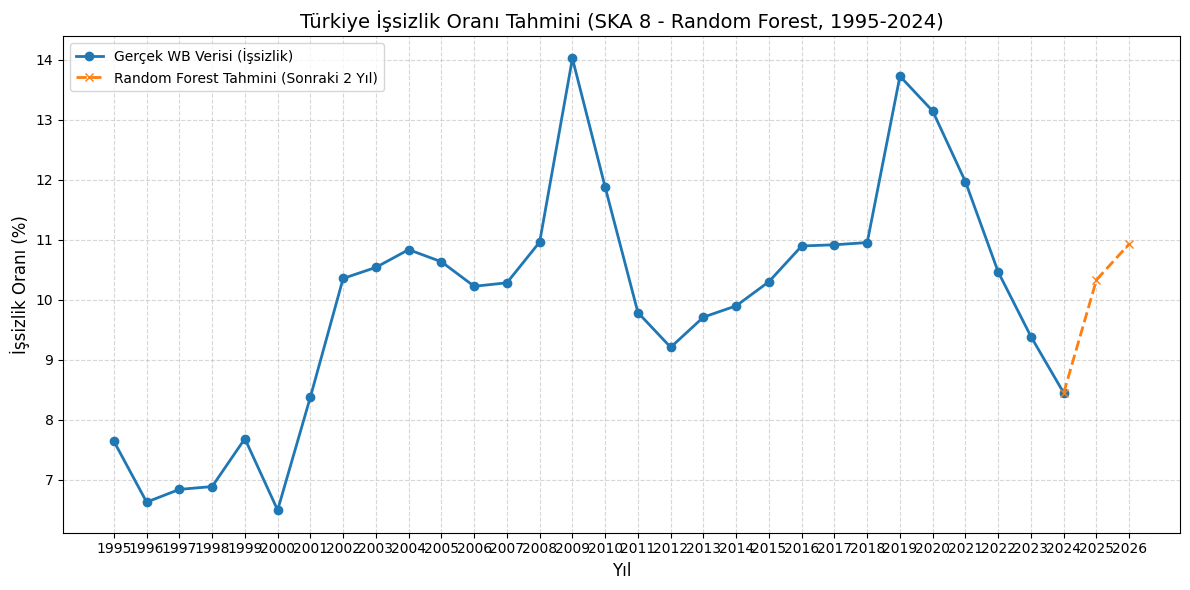


✅ İşlem tamamlandı.


In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# ---------------------------------------------------
# 1) WORLD BANK'TAN GÖSTERGE ÇEKEN YARDIMCI FONKSİYON
# ---------------------------------------------------
def fetch_indicator(indicator_code: str, col_name: str) -> pd.DataFrame:
    """
    World Bank API'den belirtilen indikatörü (indicator_code)
    Türkiye (TUR) için JSON formatında çeker ve
    Year + değer kolonuna sahip bir DataFrame döner.
    """
    url = f"https://api.worldbank.org/v2/country/TUR/indicator/{indicator_code}?format=json&per_page=2000"
    resp = requests.get(url)
    resp.raise_for_status()
    data = resp.json()

    records = data[1]
    rows = []
    for rec in records:
        value = rec.get("value")
        year = rec.get("date")
        if value is not None and year is not None:
            try:
                year_int = int(year)
            except ValueError:
                continue
            rows.append({"Year": year_int, col_name: float(value)})

    df = pd.DataFrame(rows)
    return df

print("1. ADIM: VERİLER DÜNYA BANKASI'NDAN ÇEKİLİYOR...")

# İşsizlik oranı (% of labor force)
unemp_df = fetch_indicator("SL.UEM.TOTL.ZS", "Issizlik_Orani")

# GSYİH büyüme oranı (yıllık %)
gdp_df = fetch_indicator("NY.GDP.MKTP.KD.ZG", "Buyume_Orani")

# Enflasyon (tüketici fiyatları, yıllık %)
inf_df = fetch_indicator("FP.CPI.TOTL.ZG", "Enflasyon")

# Üç göstergenin YEAR üzerinden birleştirilmesi
df = (
    unemp_df
    .merge(gdp_df, on="Year", how="inner")
    .merge(inf_df, on="Year", how="inner")
)

# ------------------ SON 30 YILI SEÇ ------------------
max_year = df["Year"].max()
min_year = max_year - 29   # son 30 yıl için

df = df[(df["Year"] >= min_year) & (df["Year"] <= max_year)].copy()
df = df.sort_values("Year").reset_index(drop=True)

print(f"\nKullanılan veri ({min_year}-{max_year}, toplam {len(df)} yıl):")
print(df)

# İstersen veri setini Excel'e kaydedebilirsin:
# df.to_excel("Proje_Veri_Seti_RF_30Yil_TS.xlsx", index=False)

# ---------------------------------------------------
# 2) MODEL İÇİN GİRİŞ (X) VE HEDEF (y)
# ---------------------------------------------------
print("\n2. ADIM: MODEL EĞİTİMİ (RANDOM FOREST, ZAMAN SERİSİ AYRIMI)")

X = df[["Year", "Buyume_Orani", "Enflasyon"]]
y = df["Issizlik_Orani"]

# ---- ZAMAN SERİSİNE UYGUN TRAIN/TEST AYRIMI ----
# Son 5 yılı test seti olarak ayırıyoruz
test_size = 5
X_train = X.iloc[:-test_size]
y_train = y.iloc[:-test_size]

X_test = X.iloc[-test_size:]
y_test = y.iloc[-test_size:]

print(f"Eğitim seti yılları: {X_train['Year'].iloc[0]} - {X_train['Year'].iloc[-1]}")
print(f"Test seti yılları   : {X_test['Year'].iloc[0]} - {X_test['Year'].iloc[-1]}")

# ---- TUNING'Lİ RANDOM FOREST MODELİ ----
model = RandomForestRegressor(
    n_estimators=500,      # ağaç sayısı (daha stabil sonuç için arttırıldı)
    max_depth=6,          # çok derin olmayan ağaçlar → overfitting azalır
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

# Test setinde tahmin ve performans
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n🎯 Model Performansı (Test Seti):")
print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

# ---------------------------------------------------
# 3) GELECEK 2 YIL İÇİN SENARYO TAHMİNİ
# ---------------------------------------------------
print("\n3. ADIM: GELECEK 2 YIL İÇİN TAHMİN")

future_years = [max_year + 1, max_year + 2]

gelecek_senaryosu = pd.DataFrame({
    "Year": future_years,
    "Buyume_Orani": [3.0, 3.5],   # senaryo büyüme beklentisi
    "Enflasyon": [45.0, 30.0]     # senaryo enflasyon beklentisi
})

tahminler = model.predict(gelecek_senaryosu)

for year, pred in zip(gelecek_senaryosu["Year"], tahminler):
    print(f"🔮 {year} tahmini işsizlik oranı: %{pred:.2f}")

# ---------------------------------------------------
# 4) GRAFİK ÇİZİMİ
# ---------------------------------------------------
print("\n4. ADIM: GRAFİK ÇİZİMİ")

plt.figure(figsize=(12, 6))

# Gerçek işsizlik verisi (son 30 yıl)
plt.plot(df["Year"], df["Issizlik_Orani"], marker="o",
         label="Gerçek WB Verisi (İşsizlik)", linewidth=2)

# Tahmin çizgisi için son yıl + senaryo yılları
yil_tahmin = [df["Year"].iloc[-1]] + future_years
issizlik_tahmin = [df["Issizlik_Orani"].iloc[-1]] + list(tahminler)

plt.plot(yil_tahmin, issizlik_tahmin, marker="x",
         linestyle="--", linewidth=2,
         label="Random Forest Tahmini (Sonraki 2 Yıl)")

plt.title(f"Türkiye İşsizlik Oranı Tahmini (SKA 8 - Random Forest, {min_year}-{max_year})",
          fontsize=14)
plt.xlabel("Yıl", fontsize=12)
plt.ylabel("İşsizlik Oranı (%)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(range(min_year, max_year + 3))
plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ İşlem tamamlandı.")

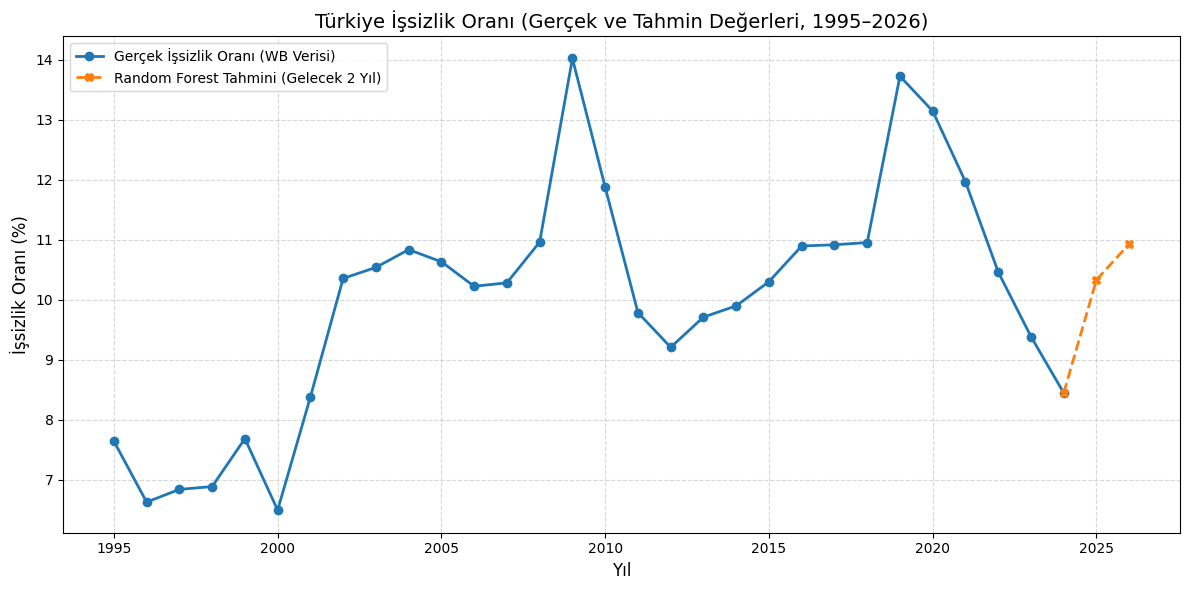

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Gerçek işsizlik verisi (son 30 yıl)
plt.plot(df["Year"], df["Issizlik_Orani"], marker="o",
         label="Gerçek İşsizlik Oranı (WB Verisi)", linewidth=2)

# Tahmin çizgisi için son yıl + gelecek yıllar
yil_tahmin = [df["Year"].iloc[-1]] + future_years
issizlik_tahmin = [df["Issizlik_Orani"].iloc[-1]] + list(tahminler)

plt.plot(yil_tahmin, issizlik_tahmin, marker="X",
         linestyle="--", linewidth=2,
         label="Random Forest Tahmini (Gelecek 2 Yıl)")

plt.title(f"Türkiye İşsizlik Oranı (Gerçek ve Tahmin Değerleri, {df['Year'].iloc[0]}–{future_years[-1]})",
          fontsize=14)
plt.xlabel("Yıl", fontsize=12)
plt.ylabel("İşsizlik Oranı (%)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

# İstersen dosya da kaydedebilirsin:
# plt.savefig("sekil1_issizlik_tahmin.png", dpi=300)

plt.show()

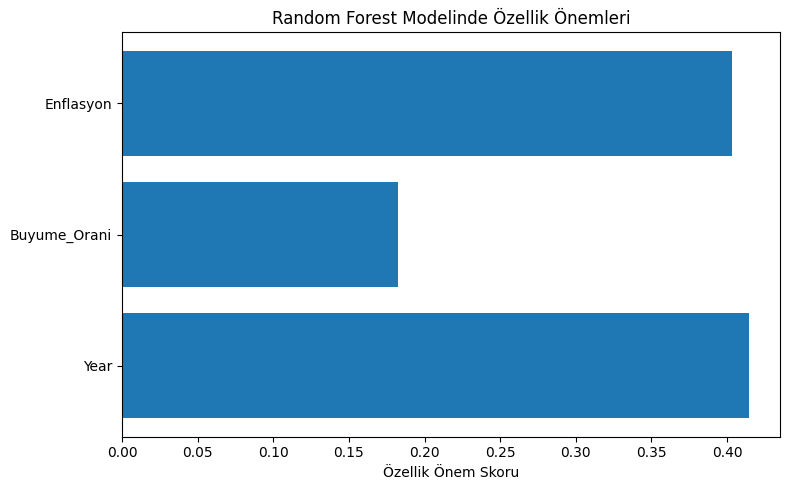

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Özellik önemleri
feature_names = ["Year", "Buyume_Orani", "Enflasyon"]
importances = model.feature_importances_

plt.figure(figsize=(8, 5))
y_pos = np.arange(len(feature_names))

plt.barh(y_pos, importances)
plt.yticks(y_pos, feature_names)
plt.xlabel("Özellik Önem Skoru")
plt.title("Random Forest Modelinde Özellik Önemleri")
plt.tight_layout()

# plt.savefig("sekil2_ozellik_onemleri.png", dpi=300)

plt.show()

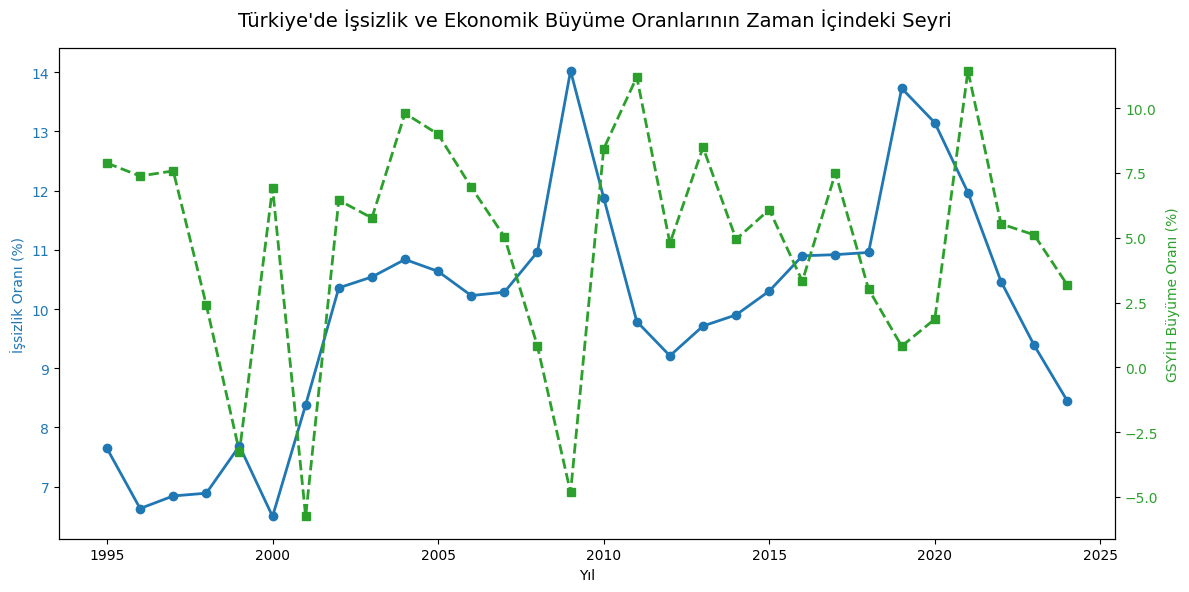

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# İşsizlik (sol eksen)
color = "tab:blue"
ax1.set_xlabel("Yıl")
ax1.set_ylabel("İşsizlik Oranı (%)", color=color)
ax1.plot(df["Year"], df["Issizlik_Orani"], marker="o", linewidth=2, label="İşsizlik Oranı", color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Büyüme (sağ eksen)
ax2 = ax1.twinx()
color = "tab:green"
ax2.set_ylabel("GSYİH Büyüme Oranı (%)", color=color)
ax2.plot(df["Year"], df["Buyume_Orani"], marker="s", linewidth=2, linestyle="--",
         label="Büyüme Oranı", color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle("Türkiye'de İşsizlik ve Ekonomik Büyüme Oranlarının Zaman İçindeki Seyri", fontsize=14)
fig.tight_layout()

# plt.savefig("sekil3_issizlik_buyume.png", dpi=300)

plt.show()

In [ ]:
pip install seaborn

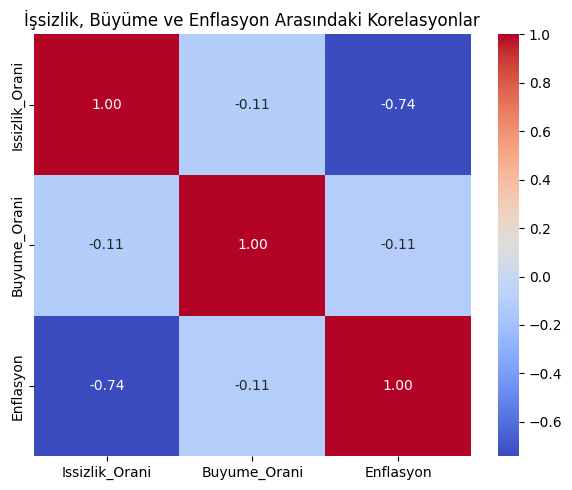

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["Issizlik_Orani", "Buyume_Orani", "Enflasyon"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("İşsizlik, Büyüme ve Enflasyon Arasındaki Korelasyonlar")
plt.tight_layout()

# plt.savefig("sekil4_korelasyon.png", dpi=300)

plt.show()